<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week10/w10_fri_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **3. 케라스(Keras)**

## **01 딥러닝 준비**
2019.09 텐서플로1 ➡️ 텐서플로2: 케라스 API를 텐서플로가 내제화
- 케라스 API: 고수준의 딥러닝 라이브러리
  - GPU 연산 수행을 직접 실행하지 않고 텐서플로, CNTK, Theano, MXNet 등 백엔드 엔진 지정해서 사용
  - 장점
    - 직관적, 사용자 친화적으로 설계돼있어 코딩의 난이도가 어렵지 않음
    - 백엔드 엔진을 쉽게 변경할 수 있다는 장점
  - 한계
    - 복잡한 구조의 모델 구현과 사용자 정의 훈련을 위해서는 텐서플로의 저수준 API를 활용해야 함
  - 케라스 2.3 버전까지는 다른 딥러닝 라이브러리 지원했지만, 2.4부터는 텐서플로만 지원

### **1-1. 주요 용어**

#### 1. 하이퍼파라미터
- 딥러닝/머신러닝 모델을 훈련할 때 사용자가 직접 설정해주는 설정 값
  - 모델이 훈련하면서 가중치(weights), 편향(bias)은 자동 업데이트, 조정되며 알아서 변하는 값
  
    ↔️
  - 학습 속도, 반복 훈련 횟수 등 사용자가 직접 설정해야 하는 값
- 어떤 값을 설정하는지에 따라 모델 성능, 결과가 달라지기 때문에 매우 중요
- 사용자가 별도로 설정하지 않으면 기본값이 자동 적용
- 하이퍼파라미터 튜닝(tuning): 하이퍼파라미터 값 조절하는 행위
  - 일반적으로 모델의 예측 성능을 위해 하이퍼파라미터 값을 조정하는 데 많은 시간 투자

#### 2. 과소적합(underfitting) vs 과대적합(overfitting)
- 훈련용 데이터를 반복학습하면서 모델을 사람이 발견하지 못하는 패턴을 학습하면서 사람의 예측 성능을 뛰어넘는 모델을 생성할 수 있음.
- But 예측할 데이터가 모델이 학습한 데이터와 다른 분포를 갖거나, 학습한 데이터가 특정 레이블에 편향된 데이터일 경우 예측 성능이 현저히 떨어짐.

- **과소적합**: 모델이 충분히 학습되지 않은 경우
- **과대적합**: 학습 데이터를 지나치게 반복 학습하여 과하게 적합된 상태
  - 훈련 데이터의 불필요한 노이즈까지 과도하게 모델에 반영되어, 예측 데이터에 대한 오차 발생 확률이 커짐

  ⏩ 과소적합, 과대적합 문제를 최소화하면서 정확도를 높일 수 있도록 해야 함

  ⏩ 훈련 데이터를 잘 구성하는 것도 중요
  - 예측 데이터와 분포가 동일하게 구성
  - 불필요한 노이즈는 데이터 분석 & 전처리를 통해 해소
  - 훈련 데이터의 일부를 검증 데이터로 활용 ➡️ 검증 성능이 가장 좋은 구간을 가장 이상적으로 학습된 지점으로 판단하고 최종 모델 결정

#### 3. 에포크(epoch)
- 딥러닝은 데이터셋 학습 과정을 여러 번 반복하면서 최적의 모델 가중치를 찾는 과정
- **epoch**: 딥러닝 모델이 반복 훈련을 할 때, 데이터셋을 전부 학습에 사용하는 1회의 훈련 루프(loop)

#### 4. 손실함수(loss function)
- 예측 값과 정답 값의 차이 또는 오차(Error)
- 일반적으로 분류나 회귀 모델에 따라 다르게 정의
```
  import tensorflow as tf

  # 클래스
  tf.keras.losses.BinaryCrossentropy()

  # 함수
  tf.keras.losses.binary_crossentropy()
```

#### 5. 경사하강법


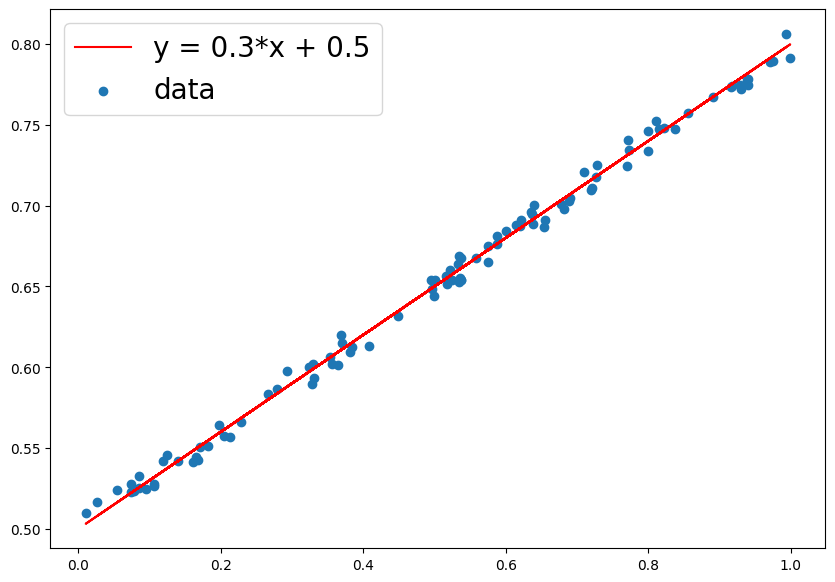

w: 0.3, b: 0.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_linear(w=0.5, b=0.8, size=50, noise=1.0):
    x = np.random.rand(size)
    y = w * x + b
    noise = np.random.uniform(-abs(noise), abs(noise), size=y.shape)
    yy = y + noise
    plt.figure(figsize=(10, 7))
    plt.plot(x, y, color='r', label=f'y = {w}*x + {b}')
    plt.scatter(x, yy, label='data')
    plt.legend(fontsize=20)
    plt.show()
    print(f'w: {w}, b: {b}')
    return x, yy

x, y = make_linear(w=0.3, b=0.5, size=100, noise=0.01)

In [ ]:
# 최대 반복 횟수
num_epoch = 1000

# 학습율 (learning_rate)
learning_rate = 0.005

# 에러 기록
errors = []

# random 한 값으로 w, b를 초기화 합니다.
w = np.random.uniform(low=0.0, high=1.0)
b = np.random.uniform(low=0.0, high=1.0)

for epoch in range(num_epoch):
    # Hypothesis 정의
    y_hat = w * x + b

    # Loss Function 정의
    error = 0.5*((y_hat - y) ** 2).sum()
    if error < 0.005:
        break
    # Gradient 미분 계산
    w = w - learning_rate * ((y_hat - y) * x).sum()
    b = b - learning_rate * (y_hat - y).sum()

    errors.append(error)

    if epoch % 5 == 0:
        print("{0:2} w = {1:.5f}, b = {2:.5f} error = {3:.5f}".format(epoch, w, b, error))

print("----" * 15)
print("{0:2} w = {1:.1f}, b = {2:.1f} error = {3:.5f}".format(epoch, w, b, error))

 0 w = 0.05222, b = 0.73421 error = 4.10635
 5 w = 0.05096, b = 0.63589 error = 0.25189
10 w = 0.08537, b = 0.61654 error = 0.18638
15 w = 0.11517, b = 0.60030 error = 0.13808
20 w = 0.14079, b = 0.58635 error = 0.10240
25 w = 0.16281, b = 0.57435 error = 0.07603
30 w = 0.18173, b = 0.56404 error = 0.05655
35 w = 0.19800, b = 0.55518 error = 0.04216
40 w = 0.21199, b = 0.54756 error = 0.03152
45 w = 0.22401, b = 0.54101 error = 0.02366
50 w = 0.23434, b = 0.53539 error = 0.01786
55 w = 0.24322, b = 0.53055 error = 0.01357
60 w = 0.25085, b = 0.52639 error = 0.01040
65 w = 0.25742, b = 0.52281 error = 0.00805
70 w = 0.26306, b = 0.51974 error = 0.00632
75 w = 0.26790, b = 0.51710 error = 0.00505
------------------------------------------------------------
76 w = 0.3, b = 0.5 error = 0.00483


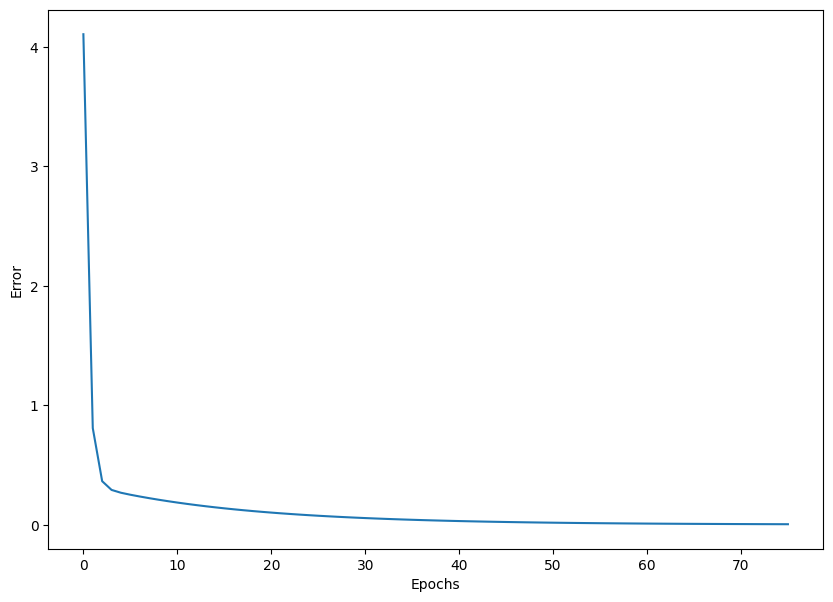

In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(errors)
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

### **1-2. 딥러닝 프로세스**
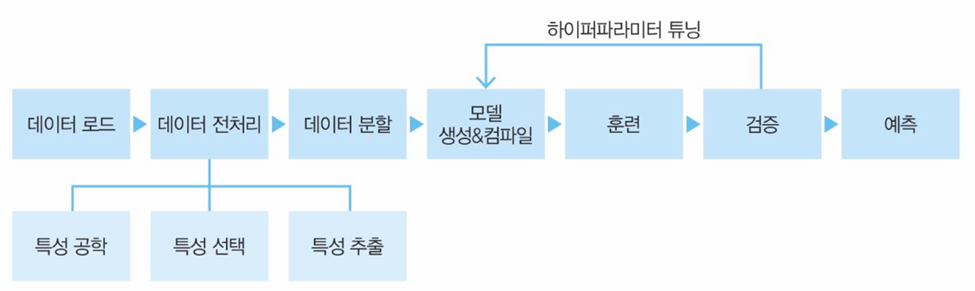

**1. 데이터 전처리**

**2. 모델 생성**

**3. 모델 컴파일**

**4. 모델 훈련**

**5. 모델 검증**

**6. 모델 에측**

## **02 단순 신경망 훈련**

### **2-1. 선형회귀**

### **2-2. 뉴런(Neuron)**

### **2-3. Dense 레이어**

```
  import tensorflow as tf

  # 10개의 노드로 이루어진 Dense 레이어
  tf.keras.layers.Dense(10)

  # ReLU 활성화 함수 적용
  tf.keras.layers.Dense(10, activation='relu')
```

### **2-4. 데이터셋 만들기**

In [ ]:
import numpy as np

# 샘플 데이터셋
x = np.arange(1, 6)

y = 3 * x + 2
print(x)
print(y)

[1 2 3 4 5]
[ 5  8 11 14 17]


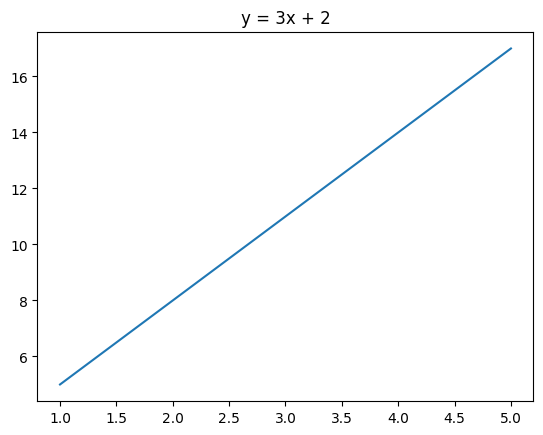

In [ ]:
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.title('y = 3x + 2')
plt.show()

### **2-5. Sequential API**

#### 1. 모델 구조

In [ ]:
import tensorflow as tf

In [ ]:
# 리스트형
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1),
])

In [ ]:
# add 함수로 레이어 추가
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(10))
model.add(tf.keras.layers.Dense(5))
model.add(tf.keras.layers.Dense(1))

#### 2. 입력 데이터 형태

In [ ]:
model = tf.keras.Sequential([
    # 입력 데이터의 shape = (150, 4) 인 경우 input_shape 지정
    tf.keras.layers.Dense(10, input_shape=[4]),
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1),
])

#### 3. 단순선형회귀 모델 생성

In [ ]:
# 단순선형회귀 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

### **2-6. 모델 요약**

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### **2-7. 컴파일**

In [ ]:
# 긴 문자열 지정
model.compile(optimizer='sgd', loss='mean_squared_error',
              metrics=['mean_squared_error', 'mean_absolute_error'])

In [ ]:
# 짧은 문자열 지정
model.compile(optimizer='sgd', loss='mse', metrics=['mse', 'mae'])

In [ ]:
# 클래스 인스턴스 지정
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.005),
              loss=tf.keras.losses.MeanAbsoluteError(),
              metrics=[tf.keras.metrics.MeanAbsoluteError(),
                       tf.keras.metrics.MeanSquaredError()
                       ])

In [ ]:
# 컴파일
model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

### **2-8. 훈련**

In [ ]:
# 훈련
history = model.fit(x, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step - loss: 135.5721 - mae: 10.8673
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 79.0947 - mae: 8.3392
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 46.1818 - mae: 6.4091
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 27.0012 - mae: 4.9355
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 15.8231 - mae: 3.8105


In [ ]:
# 단순 선형회귀 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

# 컴파일
model.compile(optimizer='sgd', loss='mse',metrics=['mae'])

# 훈련
history = model.fit(x,y,epochs=1200)

Epoch 1/1200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step - loss: 138.6434 - mae: 10.9863
Epoch 2/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 80.8828 - mae: 8.4296
Epoch 3/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 47.2221 - mae: 6.4777
Epoch 4/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 27.6058 - mae: 4.9875
Epoch 5/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 16.1738 - mae: 3.8498
Epoch 6/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9.5112 - mae: 2.9811
Epoch 7/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 5.6280 - mae: 2.3179
Epoch 8/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.3645 - mae: 1.8114
Epoch 9/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.0448 - mae: 1.4247
Epoch 10/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.2752 - mae: 1.1293
Epoch 11/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8262 - mae: 0.9036
Epoch 12/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5640 - mae: 0.7312
Epoch 13/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

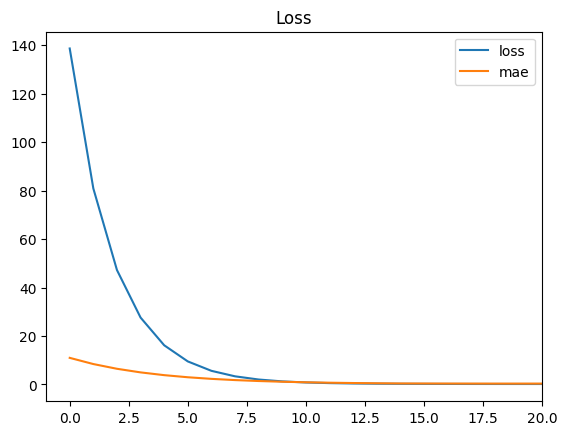

In [ ]:
import matplotlib.pyplot as plt

# 20 에포크까지 Loss 수렴에 대한 시각화
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['mae'], label='mae')
plt.xlim(-1, 20)
plt.title('Loss')
plt.legend()
plt.show()

### **2-9. 검증**

In [ ]:
# 검증
model.evaluate(x, y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 4.7635e-05 - mae: 0.0059


[4.763487231684849e-05, 0.005923938937485218]

### **2-10. 예측**

In [48]:
# 예측
model.predict(np.array([10]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[32.03305]], dtype=float32)

- 정답값인 32와 근사한 값으로 예측됨

## **3. 심층 신경망으로 이미지 분류**

### **3-1. 케라스 내장 데이터셋 로드**

In [49]:
import tensorflow as tf

# 케라스의 내장 데이터셋에서 mnist 데이터셋을 로드
mnist = tf.keras.datasets.mnist

In [50]:
# load_data()로 데이터셋을 로드 합니다.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [52]:
# 로드된 데이터셋 확인
print('train set: ', x_train.shape, y_train.shape)
print('test  set: ', x_test.shape, y_test.shape)

train set:  (60000, 28, 28) (60000,)
test  set:  (10000, 28, 28) (10000,)


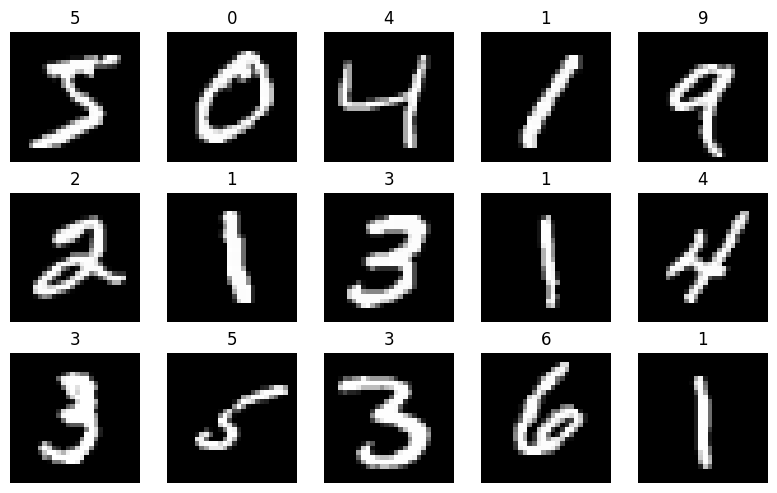

In [53]:
# 데이터 시각화
import matplotlib.pyplot as plt

# canvas 생성
fig, axes = plt.subplots(3, 5)
fig.set_size_inches(8, 5)

for i in range(15):
    ax = axes[i//5, i%5]
    # imshow로 이미지 시각화
    ax.imshow(x_train[i], cmap='gray')
    ax.axis('off')
    ax.set_title(str(y_train[i]))

plt.tight_layout()
plt.show()

### **3-2. 데이터 전처리**

In [54]:
# x_train 배열의 데이터 확인
x_train[0, 10:15, 10:15]

array([[  1, 154, 253,  90,   0],
       [  0, 139, 253, 190,   2],
       [  0,  11, 190, 253,  70],
       [  0,   0,  35, 241, 225],
       [  0,   0,   0,  81, 240]], dtype=uint8)

In [55]:
# 픽셀 값의 최소/최대 값 확인
print(f'정규화 전] 최소값: {x_train.min()}, 최대값: {x_train.max()}')

# 데이터 정규화
x_train = x_train / x_train.max()

# 정규화 후 최소/최대 값 확인
print(f'정규화 후] 최소값: {x_train.min()}, 최대값: {x_train.max()}')

정규화 전] 최소값: 0, 최대값: 255
정규화 후] 최소값: 0.0, 최대값: 1.0


In [56]:
# test 셋에도 정규화 동일 적용
x_test = x_test / x_test.max()

In [57]:
# 변환 후 x_train 배열의 데이터 확인
x_train[0, 10:15, 10:15]

array([[0.00392157, 0.60392157, 0.99215686, 0.35294118, 0.        ],
       [0.        , 0.54509804, 0.99215686, 0.74509804, 0.00784314],
       [0.        , 0.04313725, 0.74509804, 0.99215686, 0.2745098 ],
       [0.        , 0.        , 0.1372549 , 0.94509804, 0.88235294],
       [0.        , 0.        , 0.        , 0.31764706, 0.94117647]])

### **3-3. Flatten 레이어**

In [58]:
print(f'변경전 shape: {x_train.shape}')
print(f'1D으로 shape 변경 후: {x_train.reshape(60000, -1).shape}')

변경전 shape: (60000, 28, 28)
1D으로 shape 변경 후: (60000, 784)


In [59]:
print(f'변경전 shape: {x_train.shape}')

# Flatten 레이어 적용 후 shape 확인
print(f'Flatten 적용 후: {tf.keras.layers.Flatten()(x_train).shape}')

변경전 shape: (60000, 28, 28)
Flatten 적용 후: (60000, 784)


### **3-4. 활성화 함수**

In [60]:
# Dense 레이어에 relu 활성화 함수를 적용한 경우
tf.keras.layers.Dense(128, activation='relu')

<Dense name=dense_21, built=False>

In [61]:
# Dense 레이어에 relu 활성화 함수를 적용한 경우
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128),
    tf.keras.layers.Activation('relu')
])

### **3-5. 입력과 출력**

In [62]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    # 노드=10개 (클래스 개수와 동일)
    tf.keras.layers.Dense(10, activation='softmax'),
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:
# 출력층 노드 = 1인 경우, sigmoid
tf.keras.layers.Dense(1, activation='sigmoid')

# 출력층 노드 = 2개 이상인 경우, softmax
tf.keras.layers.Dense(10, activation='softmax')

<Dense name=dense_28, built=False>

### **3-6. 손실함수**

In [64]:
# 이진 분류 (출력 노드 개수 = 1, sigmoid 인 경우)
model.compile(loss='binary_crossentropy')

In [65]:
# y가 원 핫 벡터인 경우
# [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]
model.compile(loss='categorical_crossentropy')

# y가 원 핫 벡터가 아닌경우
# [5]
model.compile(loss='sparse_categorical_crossentropy')

### **3-7. 옵티마이저**

In [67]:
# 클래스 인스턴스로 지정
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam)

# 문자열로 지정
model.compile(optimizer='adam')

### **3-8. 평가지표**

In [68]:
# 클래스 인스턴스로 지정
acc = tf.keras.metrics.SparseCategoricalAccuracy()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=[acc])

In [69]:
# 문자열로 지정
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### **3-9. 훈련**

In [70]:
# 훈련
model.fit(x_train, y_train,
          # 검증셋 지정
          validation_data=(x_test, y_test),
          epochs=10,
          )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8707 - loss: 0.4369 - val_accuracy: 0.9640 - val_loss: 0.1207
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9697 - loss: 0.0992 - val_accuracy: 0.9762 - val_loss: 0.0842
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9792 - loss: 0.0666 - val_accuracy: 0.9738 - val_loss: 0.0877
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9844 - loss: 0.0493 - val_accuracy: 0.9752 - val_loss: 0.0804
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9877 - loss: 0.0366 - val_accuracy: 0.9730 - val_loss: 0.0927
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9901 - loss: 0.0295 - val_accuracy: 0.9796 - val_loss: 0.0741
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9908 - loss: 0.0268 - val_accuracy: 0.9794 - val_loss: 0.0909
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9937 - loss: 0

### **3-10. 평가**

In [70]:
# 검증
test_loss, test_acc = model.evaluate(x_test,  y_test)

print('검증셋 정확도:', test_acc)

### **3-11. 예측**

In [71]:
# 예측
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [72]:
# 예측 결과 출력
predictions[0]

array([1.9580832e-12, 2.2734017e-08, 2.0855651e-09, 9.7763992e-09,
       1.5365671e-10, 1.5334650e-12, 6.1592901e-17, 9.9999994e-01,
       9.6244945e-10, 2.4128887e-08], dtype=float32)

In [73]:
import numpy as np

# 0번 index에 대한 예측 클래스 출력
print(np.argmax(predictions[0]))

# 첫 10개 index에 대한 예측 클래스 출력
print(np.argmax(predictions[:10], axis=1))

7
[7 2 1 0 4 1 4 9 5 9]


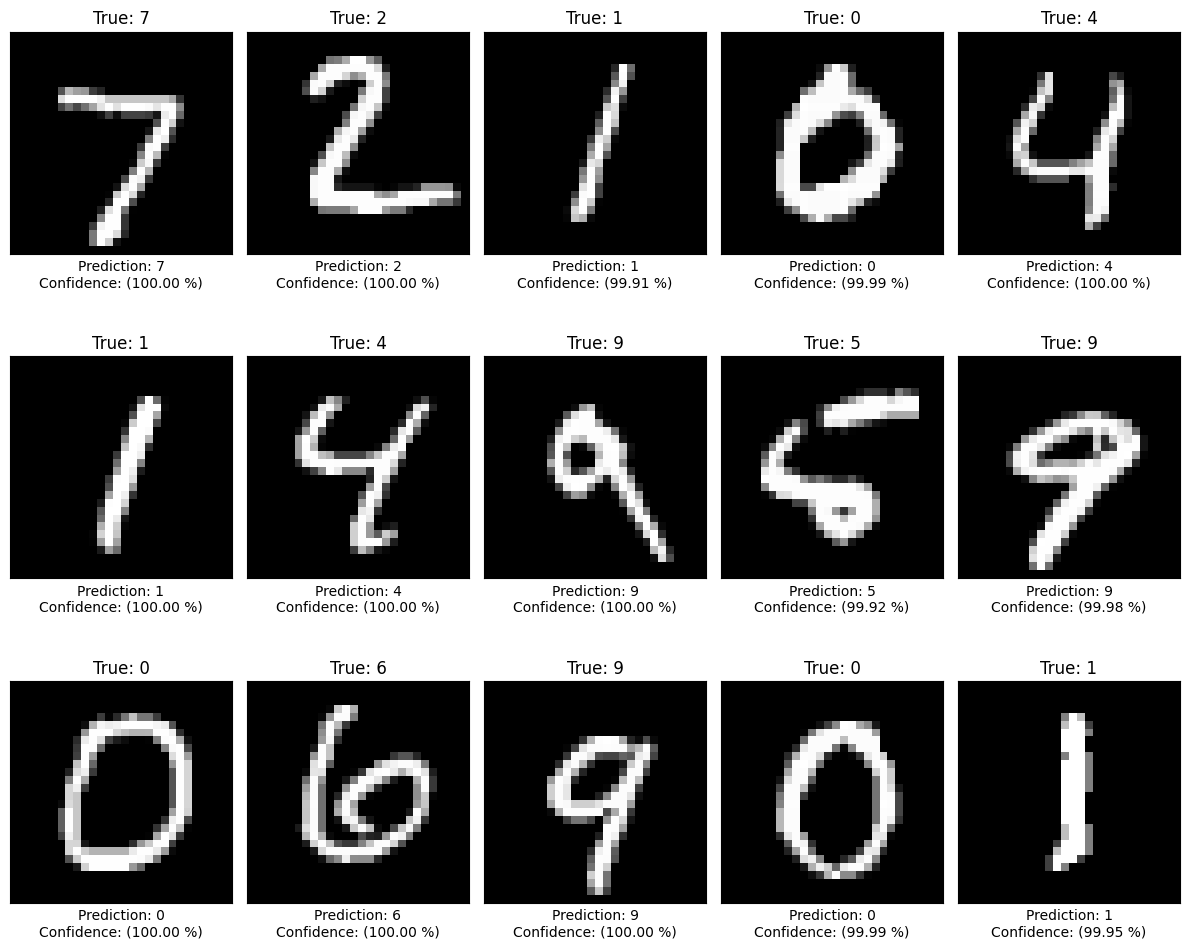

In [74]:
# 데이터 시각화
import matplotlib.pyplot as plt

def get_one_result(idx):
    img, y_true, y_pred, confidence = x_test[idx], y_test[idx], np.argmax(predictions[idx]), 100*np.max(predictions[idx])
    return img, y_true, y_pred, confidence

# canvas 생성
fig, axes = plt.subplots(3, 5)
fig.set_size_inches(12, 10)

for i in range(15):
    ax = axes[i//5, i%5]

    img, y_true, y_pred, confidence = get_one_result(i)

    # imshow로 이미지 시각화
    ax.imshow(img, cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'True: {y_true}')
    ax.set_xlabel(f'Prediction: {y_pred}\nConfidence: ({confidence:.2f} %)')

plt.tight_layout()
plt.show()